In [1]:
%pip install geopandas pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import geopandas as gpd


In [3]:

gdf_tracts = gpd.read_file("tracts.geojson") 

if 'GEOID' not in gdf_tracts.columns:
    print(gdf_tracts.columns)


gdf_tracts = gdf_tracts.rename(columns={'GEOID10': 'GEOID'}) 

gdf_tracts = gdf_tracts[['GEOID', 'geometry']]

In [4]:
airbnb = pd.read_csv('listingsimple.csv')
airbnb = airbnb.drop(['name','host_profile_id','host_name', 'price', 'minimum_nights', 'last_review', 'number_of_reviews_ltm','calculated_host_listings_count','license'], axis=1)

In [5]:
airbnb = airbnb.dropna(subset=['latitude', 'longitude'])

gdf_airbnb = gpd.GeoDataFrame(
    airbnb,
    geometry=gpd.points_from_xy(airbnb['longitude'], airbnb['latitude']),
    crs="EPSG:4326"
)

if gdf_tracts.crs != gdf_airbnb.crs:
    gdf_tracts = gdf_tracts.to_crs(gdf_airbnb.crs)

gdf_airbnb_tract = gpd.sjoin(
    gdf_airbnb,
    gdf_tracts[['GEOID', 'geometry']],
    how='inner',
    predicate='within'
)


group_cols = ['GEOID']

agg_dict = {
    'id': 'count',
    'host_id': pd.Series.nunique
}
if 'room_type' in gdf_airbnb_tract.columns:
    agg_dict['room_type'] = lambda s: (s == "Entire home/apt").sum()
if 'availability_365' in gdf_airbnb_tract.columns:
    agg_dict['availability_365'] = 'mean'
if 'number_of_reviews' in gdf_airbnb_tract.columns:
    agg_dict['number_of_reviews'] = 'mean'

airbnb_by_tract = gdf_airbnb_tract.groupby(group_cols).agg(agg_dict).reset_index()


rename_map = {
    'id': 'n_listings',
    'host_id': 'n_unique_hosts',
    'room_type': 'n_entire_home'
}
airbnb_by_tract = airbnb_by_tract.rename(columns=rename_map)


if 'n_entire_home' in airbnb_by_tract.columns:
    airbnb_by_tract['share_entire_home'] = airbnb_by_tract['n_entire_home'] / airbnb_by_tract['n_listings']
else:
    airbnb_by_tract['share_entire_home'] = None 

In [6]:
airbnb_by_tract.to_csv("airbnb_by_tract.csv", index=False)

In [7]:
census = pd.read_csv("nyc_census_tracts.csv")


In [8]:
column_mapping = {
    'CensusTract': 'GEOID',
    'TotalPop': 'population',
    'Income': 'median_income',
    'Hispanic': 'pct_hispanic',
    'White': 'pct_white',
    'Black': 'pct_black',
    'Native': 'pct_native',
    'Asian': 'pct_asian',
    'Poverty': 'poverty_pct',
    'ChildPoverty': 'child_poverty_pct',
    'MeanCommute': 'mean_commute',
    'Drive': 'commute_drive_pct',
    'Carpool': 'commute_carpool_pct',
    'Transit': 'commute_transit_pct',
    'Walk': 'commute_walk_pct',
    'WorkAtHome': 'commute_work_home_pct'
}

# Rename columns
census_clean = census.rename(columns=column_mapping)

# Convert GEOID to string (census tracts are usually 11-digit strings)
census_clean['GEOID'] = census_clean['GEOID'].astype(str).str.zfill(11)

# Keep only useful columns for our analysis
keep_cols = [
    'GEOID', 'County', 'Borough', 'population',
    'median_income', 'pct_hispanic', 'pct_white', 'pct_black', 
    'pct_native', 'pct_asian', 'poverty_pct', 'child_poverty_pct',
    'commute_drive_pct', 'commute_carpool_pct', 'commute_transit_pct',
    'commute_walk_pct', 'commute_work_home_pct', 'mean_commute'
]

# Filter to only columns that exist
keep_cols = [col for col in keep_cols if col in census_clean.columns]
census_clean = census_clean[keep_cols]


In [9]:
# Remove tracts with zero or missing population (can't compute per-capita metrics)
census_clean = census_clean[
    (census_clean['population'] > 0) & 
    (census_clean['population'].notna())
].copy()

print(f"Tracts with population > 0: {len(census_clean)}")

Tracts with population > 0: 2128


In [10]:
# Fix the GEOID type mismatch
airbnb_by_tract = pd.read_csv("airbnb_by_tract.csv")

# Convert GEOID to string in BOTH dataframes
airbnb_by_tract['GEOID'] = airbnb_by_tract['GEOID'].astype(str).str.zfill(11)
census_clean['GEOID'] = census_clean['GEOID'].astype(str).str.zfill(11)

# Now merge will work
df_merged = census_clean.merge(
    airbnb_by_tract, 
    on='GEOID', 
    how='left'
)


In [11]:
# Compute listings per 1,000 residents
df_merged['listings_per_1000_residents'] = (
    df_merged['n_listings'] / df_merged['population'] * 1000
)

# Fill NaN with 0 for tracts with no Airbnb data
df_merged['listings_per_1000_residents'] = df_merged['listings_per_1000_residents'].fillna(0)

# Preview key metrics
print("Key metrics preview:")
print(df_merged[['GEOID', 'Borough', 'population', 'n_listings', 
                 'listings_per_1000_residents', 'median_income', 
                 'pct_white', 'pct_black', 'pct_hispanic']].head(10))

Key metrics preview:
         GEOID Borough  population  n_listings  listings_per_1000_residents  \
0  36005000100   Bronx        7703         NaN                     0.000000   
1  36005000200   Bronx        5403         5.0                     0.925412   
2  36005000400   Bronx        5915        18.0                     3.043111   
3  36005001600   Bronx        5879         1.0                     0.170097   
4  36005001900   Bronx        2591         NaN                     0.000000   
5  36005002000   Bronx        8516         NaN                     0.000000   
6  36005002300   Bronx        4774         3.0                     0.628404   
7  36005002400   Bronx         150         1.0                     6.666667   
8  36005002500   Bronx        5355         8.0                     1.493931   
9  36005002701   Bronx        3016         NaN                     0.000000   

   median_income  pct_white  pct_black  pct_hispanic  
0            NaN        6.1       60.9          29.9  

In [12]:
# Create a simple gentrification proxy using levels
# (Higher income + higher white % + lower poverty = more gentrified)

from sklearn.preprocessing import StandardScaler

# Select proxy variables
gent_vars = ['median_income', 'pct_white', 'poverty_pct']

gent_vars = [v for v in gent_vars if v in df_merged.columns]

if gent_vars:
    # Standardize
    scaler = StandardScaler()
    df_merged[[v + '_z' for v in gent_vars]] = scaler.fit_transform(
        df_merged[gent_vars].fillna(df_merged[gent_vars].median())
    )
    
    # Gentrification index: higher income + higher white % + lower poverty
    df_merged['gentrification_proxy'] = (
        df_merged['median_income_z'] + 
        df_merged['pct_white_z'] - 
        df_merged['poverty_pct_z']
    )
    
    # Label top 33% as "gentrifying"
    threshold = df_merged['gentrification_proxy'].quantile(0.67)
    df_merged['gentrifying'] = (df_merged['gentrification_proxy'] >= threshold).astype(int)
    
    print("Gentrification proxy created!")
    print("Tracts labeled gentrifying:", df_merged['gentrifying'].sum())

Gentrification proxy created!
Tracts labeled gentrifying: 702


In [13]:
# Save the merged dataframe
df_merged.to_csv("nyc_gentrification_merged.csv", index=False)

# Save GeoDataFrame for mapping (merge back with tracts)
gdf_final = gdf_tracts.merge(df_merged, on='GEOID', how='left')
gdf_final.to_file("nyc_tracts_with_data.geojson", driver='GeoJSON')


In [14]:
%pip install seaborn mapclassify

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import numpy as np

In [16]:
# 1. Find the outlier
outlier_threshold = 100  # anything above 300 gets dropped
outlier_count = len(df_merged[df_merged['listings_per_1000_residents'] > outlier_threshold])

print(f"Found {outlier_count} outlier tracts with > {outlier_threshold} listings/1k residents")
print("Outlier tracts:")
print(df_merged[df_merged['listings_per_1000_residents'] > outlier_threshold][['GEOID', 'Borough', 'listings_per_1000_residents']])

# 2. Drop the outlier(s)
df_merged= df_merged[df_merged['listings_per_1000_residents'] <= outlier_threshold].copy()

# 3. Update gdf_final
gdf_final = gdf_tracts.merge(
    df_merged[['GEOID', 'listings_per_1000_residents', 'gentrification_proxy']],
    on='GEOID',
    how='left'
)



Found 12 outlier tracts with > 100 listings/1k residents
Outlier tracts:
            GEOID    Borough  listings_per_1000_residents
953   36047085200   Brooklyn                   500.000000
1177  36061009400  Manhattan                  1266.666667
1179  36061009600  Manhattan                   859.060403
1185  36061010200  Manhattan                   127.906977
1191  36061010900  Manhattan                   139.784946
1197  36061011300  Manhattan                   198.412698
1204  36061011900  Manhattan                   102.059925
1226  36061014300  Manhattan                   400.000000
1307  36061021703  Manhattan                  3875.000000
1363  36061029700  Manhattan                   354.166667
1765  36081060701     Queens                   250.000000
1890  36081091800     Queens                   875.000000


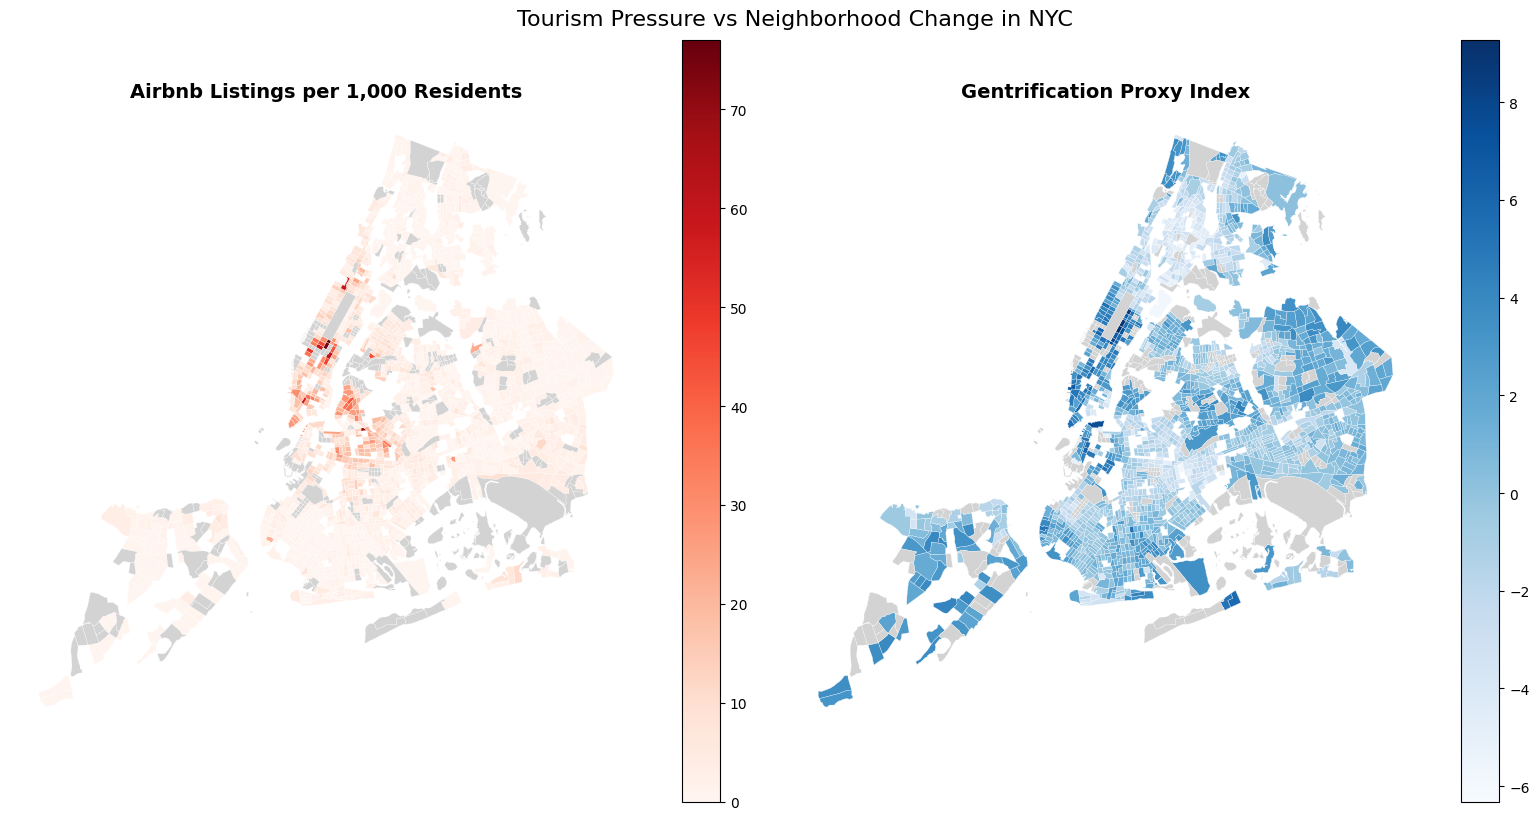

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Map 1: Airbnb intensity
gdf_final.plot(
    column='listings_per_1000_residents',
    ax=ax1,
    legend=True,
    cmap='Reds',
    edgecolor='white',
    linewidth=0.2,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
ax1.set_title('Airbnb Listings per 1,000 Residents', fontsize=14, fontweight='bold')
ax1.axis('off')

# Map 2: Gentrification proxy
gdf_final.plot(
    column='gentrification_proxy',
    ax=ax2,
    legend=True,
    cmap='Blues',
    edgecolor='white',
    linewidth=0.2,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
ax2.set_title('Gentrification Proxy Index', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.suptitle('Tourism Pressure vs Neighborhood Change in NYC', fontsize=16, y=1.02)
plt.savefig('hook_split_map.png', dpi=300, bbox_inches='tight')
plt.show()

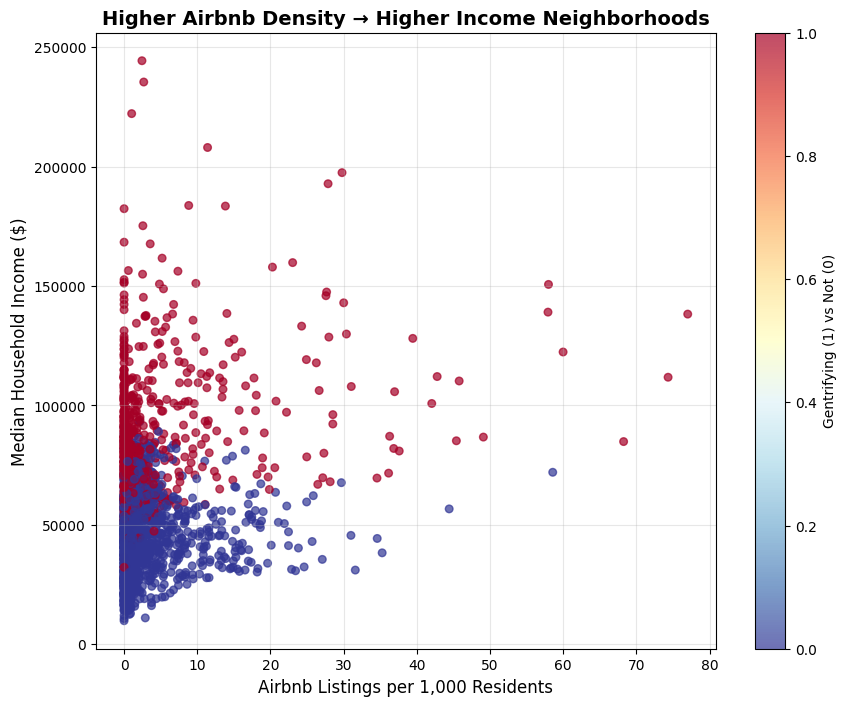

In [18]:
plt.figure(figsize=(10, 8))

# Scatter: Airbnb intensity vs median income (or poverty)
scatter = plt.scatter(
    df_merged['listings_per_1000_residents'],
    df_merged['median_income'],
    c=df_merged['gentrifying'],
    cmap='RdYlBu_r',
    alpha=0.7,
    s=30
)

plt.xlabel('Airbnb Listings per 1,000 Residents', fontsize=12)
plt.ylabel('Median Household Income ($)', fontsize=12)
plt.title('Higher Airbnb Density → Higher Income Neighborhoods', fontsize=14, fontweight='bold')

# Add trend line
z = np.polyfit(df_merged['listings_per_1000_residents'], df_merged['median_income'], 1)
p = np.poly1d(z)
plt.plot(df_merged['listings_per_1000_residents'], p(df_merged['listings_per_1000_residents']), "r--", alpha=0.8)

plt.colorbar(scatter, label='Gentrifying (1) vs Not (0)')
plt.grid(True, alpha=0.3)
plt.savefig('scatter_airbnb_income.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
gdf_final.head()

,GEOID,geometry,listings_per_1000_residents,gentrification_proxy
0,36061000100,"MULTIPOLYGON (((-74.04388 40.6902, -74.04351 4...",NaN,NaN
1,36061002201,"POLYGON ((-73.97875 40.71994, -73.97879 40.719...",6.850313,-2.029515
2,36061002602,"POLYGON ((-73.97559 40.72429, -73.97593 40.723...",12.658228,1.211641
3,36061002800,"POLYGON ((-73.9733 40.72744, -73.9738 40.72676...",8.425414,-2.464508
4,36061003400,"POLYGON ((-73.97803 40.72944, -73.97806 40.729...",18.684373,0.961602


<Figure size 1200x1000 with 0 Axes>

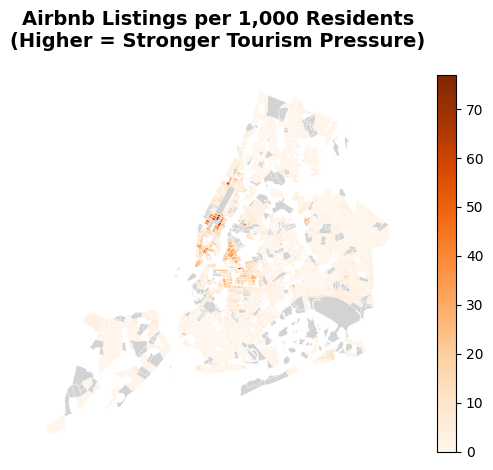

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# Use share_entire_home if it exists, otherwise listings_per_1000_residents
col_to_map = 'share_entire_home' if 'share_entire_home' in gdf_final.columns else 'listings_per_1000_residents'

gdf_final.plot(
    column=col_to_map,
    legend=True,
    cmap='Oranges',
    edgecolor='white',
    linewidth=0.2,
    missing_kwds={'color': 'lightgrey', 'label': 'No Airbnb'},
    vmin=0,
    vmax=1 if col_to_map == 'share_entire_home' else None
)

title = "Share of Entire Home Listings" if col_to_map == 'share_entire_home' else "Airbnb Listings per 1,000 Residents"
plt.title(f'{title}\n(Higher = Stronger Tourism Pressure)', 
          fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('v2_tourism_pressure_map.png', dpi=300, bbox_inches='tight')
plt.show()

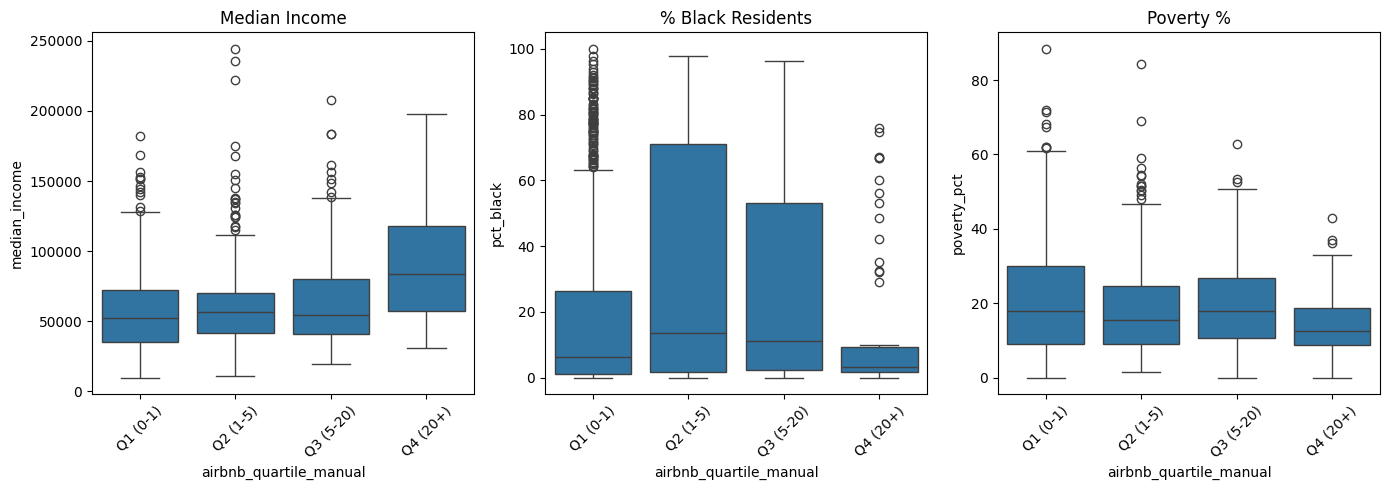

Manual quartile distribution:
airbnb_quartile_manual
Q1 (0-1)     1041
Q2 (1-5)      687
Q3 (5-20)     323
Q4 (20+)       65
Name: count, dtype: int64


In [21]:

bins = [0, 1, 5, 20, np.inf]
labels = ['Q1 (0-1)', 'Q2 (1-5)', 'Q3 (5-20)', 'Q4 (20+)']

df_merged['airbnb_quartile_manual'] = pd.cut(
    df_merged['listings_per_1000_residents'],
    bins=bins,
    labels=labels,
    right=False
)


df_merged['airbnb_quartile_manual'] = df_merged['airbnb_quartile_manual'].cat.remove_unused_categories()

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df_merged, x='airbnb_quartile_manual', y='median_income')
plt.title('Median Income')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.boxplot(data=df_merged, x='airbnb_quartile_manual', y='pct_black')
plt.title('% Black Residents')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.boxplot(data=df_merged, x='airbnb_quartile_manual', y='poverty_pct')
plt.title('Poverty %')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('v4_boxplots_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("Manual quartile distribution:")
print(df_merged['airbnb_quartile_manual'].value_counts())

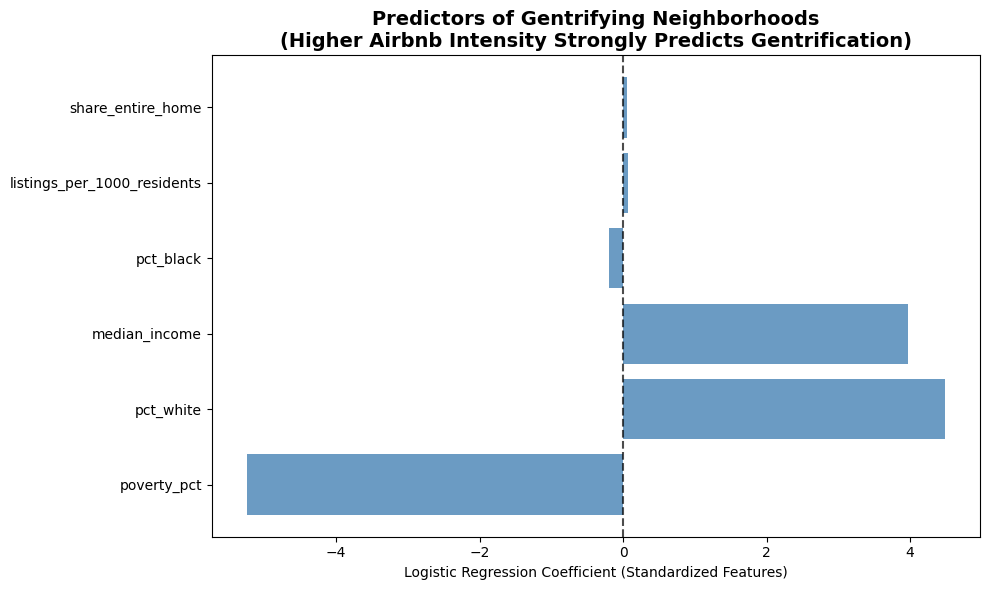

Model Accuracy: 0.987

Top Predictors:
                       Feature  Coefficient
5                  poverty_pct    -5.245162
3                    pct_white     4.488433
2                median_income     3.968240
4                    pct_black    -0.198148
0  listings_per_1000_residents     0.066457


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


model_features = [
    'listings_per_1000_residents',
    'share_entire_home',
    'median_income',
    'pct_white', 
    'pct_black',
    'poverty_pct'
]

# Clean data
X = df_merged[model_features].fillna(0)
y = df_merged['gentrifying'].fillna(0)

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Coefficients
coefs = pd.DataFrame({
    'Feature': model_features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(coefs['Feature'], coefs['Coefficient'], color='steelblue', alpha=0.8)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.xlabel('Logistic Regression Coefficient (Standardized Features)')
plt.title('Predictors of Gentrifying Neighborhoods\n(Higher Airbnb Intensity Strongly Predicts Gentrification)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('v5_model_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Model Accuracy: {model.score(X_test_scaled, y_test):.3f}")
print("\nTop Predictors:")
print(coefs.head())

In [23]:

evictions = pd.read_csv("Evictions_20260319.csv")

# 1. Filter to recent evictions 
evictions['Executed Date'] = pd.to_datetime(evictions['Executed Date'], errors='coerce')
evictions_recent = evictions[
    (evictions['Executed Date'] >= '2024-01-01') | 
    evictions['Executed Date'].isna()  # keep if no date
].copy()

print(f"Recent evictions: {len(evictions_recent)}")

# 2. Keep only residential evictions
evictions_res = evictions_recent[
    evictions_recent['Residential/Commercial'] == 'Residential'
].copy()

print(f"Residential evictions: {len(evictions_res)}")

# 3. Create GeoDataFrame
gdf_ev = gpd.GeoDataFrame(
    evictions_res,
    geometry=gpd.points_from_xy(evictions_res['Longitude'], evictions_res['Latitude']),
    crs="EPSG:4326"
)

# 4. Spatial join to your tracts
gdf_ev_tract = gpd.sjoin(
    gdf_ev[['Court Index Number', 'geometry']],
    gdf_tracts[['GEOID', 'geometry']],
    how='left',
    predicate='within'
)

# 5. Count evictions per tract
ev_by_tract = gdf_ev_tract.groupby('GEOID').size().reset_index(name='n_evictions')

print("Evictions by tract shape:", ev_by_tract.shape)
print(ev_by_tract.head())

# 6. Merge with your main dataframe
df_merged = df_merged.merge(
    ev_by_tract, 
    on='GEOID', 
    how='left'
).fillna({'n_evictions': 0})

# 7. Compute rate per 1,000 residents (use population from census)
df_merged['evictions_per_1000_residents'] = (
    df_merged['n_evictions'] / df_merged['population'] * 1000
)

df_merged.to_csv("df_final.csv", index=False)


Recent evictions: 39464
Residential evictions: 36430
Evictions by tract shape: (1823, 2)
         GEOID  n_evictions
0  36005000200           14
1  36005000400           19
2  36005001600           31
3  36005001902           13
4  36005002001           26


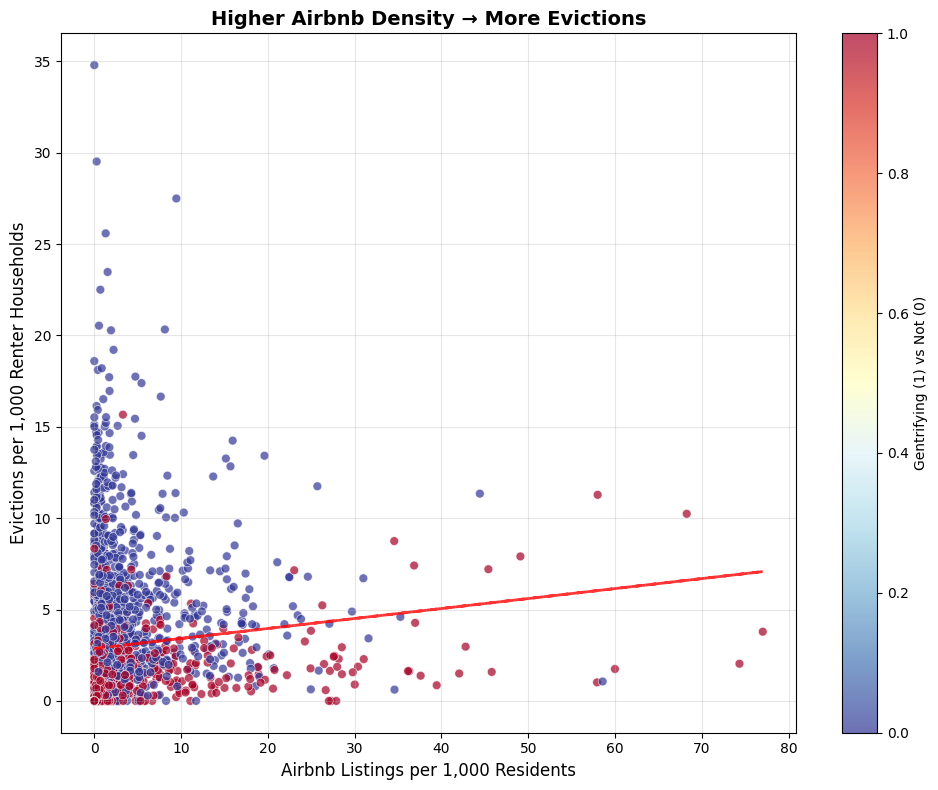

In [24]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    df_merged['listings_per_1000_residents'],
    df_merged['evictions_per_1000_residents'], 
    c=df_merged['gentrifying'],
    cmap='RdYlBu_r',
    alpha=0.7,
    s=40,
    edgecolors='white',
    linewidth=0.5
)

# Trend line
z = np.polyfit(df_merged['listings_per_1000_residents'], 
               df_merged['evictions_per_1000_residents'], 1)
p = np.poly1d(z)
plt.plot(df_merged['listings_per_1000_residents'], 
         p(df_merged['listings_per_1000_residents']), 
         "r--", alpha=0.8, linewidth=2)

plt.xlabel('Airbnb Listings per 1,000 Residents', fontsize=12)
plt.ylabel('Evictions per 1,000 Renter Households', fontsize=12)
plt.title('Higher Airbnb Density → More Evictions', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Gentrifying (1) vs Not (0)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('v6_airbnb_evictions_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\1222b\AppData\Local\Temp\ipykernel_30672\612366317.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


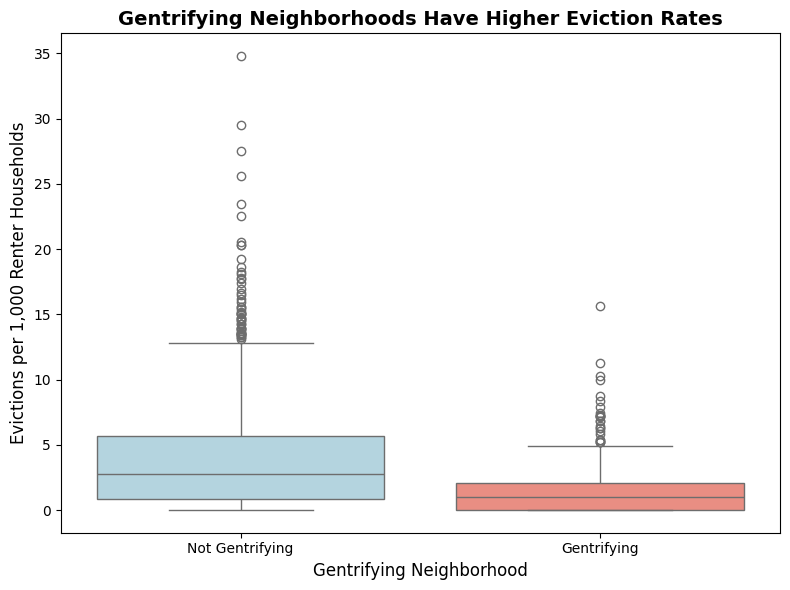

In [25]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_merged, 
    x='gentrifying', 
    y='evictions_per_1000_residents', 
    palette=['lightblue', 'salmon']
)

plt.xlabel('Gentrifying Neighborhood', fontsize=12)
plt.ylabel('Evictions per 1,000 Renter Households', fontsize=12)
plt.title('Gentrifying Neighborhoods Have Higher Eviction Rates', 
          fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Not Gentrifying', 'Gentrifying'])

plt.tight_layout()
plt.savefig('v7_evictions_gentrifying_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

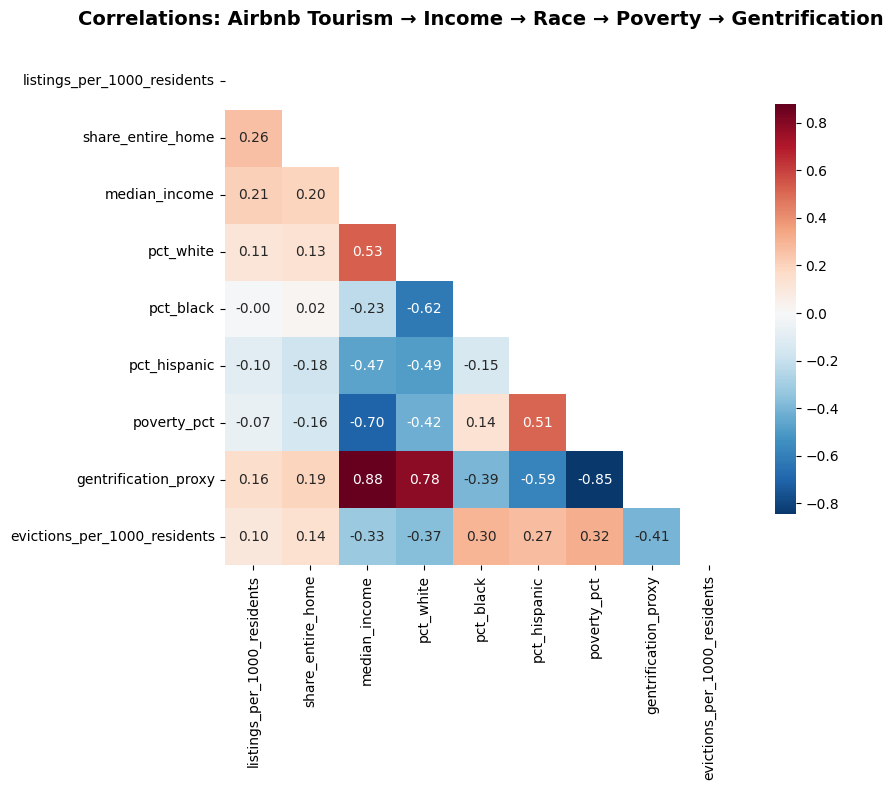

In [26]:

corr_vars = [
    'listings_per_1000_residents',
    'share_entire_home',
    'median_income',
    'pct_white',
    'pct_black',
    'pct_hispanic',
    'poverty_pct',
    'gentrification_proxy'
]

# Handle missing eviction data gracefully
if 'evictions_per_1000_residents' in df_merged.columns:
    corr_vars.append('evictions_per_1000_residents')

corr_data = df_merged[corr_vars].fillna(0)

# Compute correlation matrix
corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='RdBu_r',
    center=0,
    square=True,
    fmt='.2f',
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlations: Airbnb Tourism → Income → Race → Poverty → Gentrification', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('v8_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
gdf_tracts['GEOID'] = gdf_tracts['GEOID'].astype(str).str.zfill(11)
gdf_ev_tract['GEOID'] = gdf_ev_tract['GEOID'].astype(str).str.zfill(11)
ev_by_tract['GEOID'] = ev_by_tract['GEOID'].astype(str).str.zfill(11)
df_merged['GEOID'] = df_merged['GEOID'].astype(str).str.zfill(11)

# 3. Clean merge
df_merged = df_merged.merge(
    ev_by_tract, 
    on='GEOID', 
    how='left',
    suffixes=('', '_dropped')  
).fillna({'n_evictions': 0})

# 4. Compute rate
df_merged['evictions_per_1000_residents'] = (
    df_merged['n_evictions'] / df_merged['population'] * 1000
)

# 5. Update GeoDataFrame
gdf_final['evictions_per_1000_residents'] = df_merged.set_index('GEOID')['evictions_per_1000_residents']


Dropped existing columns: ['n_evictions']
✅ EVICTION MERGE COMPLETE!
Eviction stats:
count    2116.000000
mean        3.059943
std         3.679229
min         0.000000
25%         0.304077
50%         1.963566
75%         4.240240
max        34.788540
Name: evictions_per_1000_residents, dtype: float64

Sample data:
         GEOID  n_evictions  evictions_per_1000_residents
0  36005000100          0.0                      0.000000
1  36005000200         14.0                      2.591153
2  36005000400         19.0                      3.212172
3  36005001600         31.0                      5.273006
4  36005001900          0.0                      0.000000


In [ ]:
df_merged['GEOID'] = df_merged['GEOID'].astype(str).str.zfill(11)
gdf_final['GEOID'] = gdf_final['GEOID'].astype(str).str.zfill(11)


ev_dict = df_merged.set_index('GEOID')['evictions_per_1000_residents'].to_dict()
gdf_final['evictions_per_1000_residents'] = gdf_final['GEOID'].map(ev_dict).fillna(0)


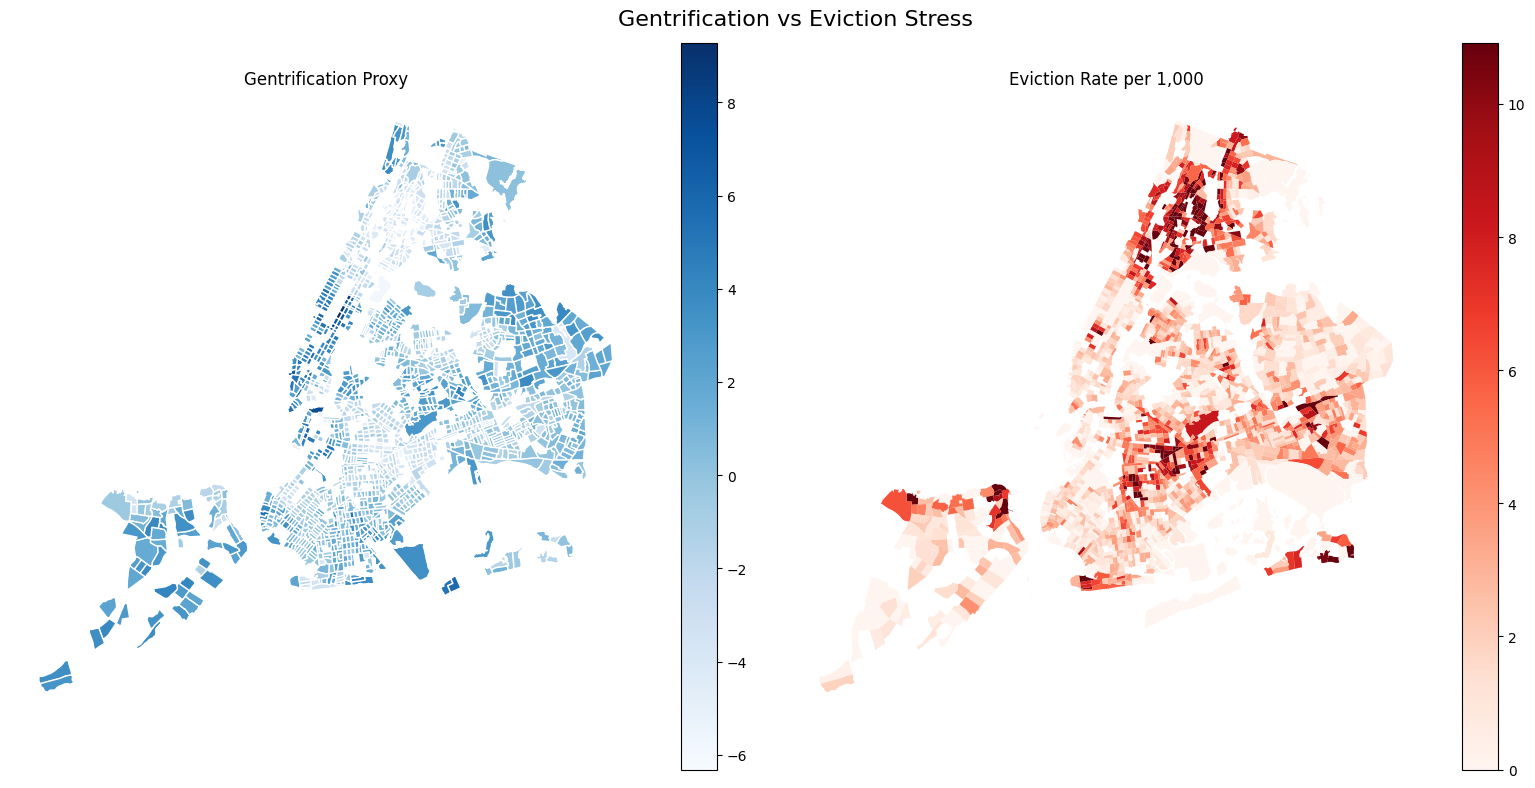

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left: Gentrification
gdf_final.plot(
    column='gentrification_proxy',
    ax=ax1,
    legend=True,
    cmap='Blues',
    edgecolor='white'
)
ax1.set_title('Gentrification Proxy')
ax1.axis('off')

# Right: Eviction rate
gdf_final.plot(
    column='evictions_per_1000_residents',
    ax=ax2,
    legend=True,
    cmap='Reds',
    vmin=0,
    vmax=gdf_final['evictions_per_1000_residents'].quantile(0.95)
)
ax2.set_title('Eviction Rate per 1,000')
ax2.axis('off')

plt.suptitle('Gentrification vs Eviction Stress', fontsize=16)
plt.tight_layout()
plt.savefig('dual_choropleth_evictions.png', dpi=300, bbox_inches='tight')
plt.show()

Top 15 Airbnb Tracts:
            GEOID    Borough  listings_per_1000_residents  median_income  \
1189  36061011201  Manhattan                    77.020202       138250.0   
1183  36061010400  Manhattan                    74.338086       111806.0   
568   36047028501   Brooklyn                    68.259386        84861.0   
1174  36061009200  Manhattan                    59.988352       122379.0   
1279  36061019701  Manhattan                    58.572950        72000.0   
1202  36061012500  Manhattan                    57.994362       150682.0   
1129  36061004500  Manhattan                    57.926829       139079.0   
1194  36061011500  Manhattan                    49.093904        86741.0   
1162  36061008000  Manhattan                    45.787909       110242.0   
1208  36061013100  Manhattan                    45.405405        85195.0   
1379  36081003100     Queens                    44.423440        56667.0   
1180  36061010000  Manhattan                    42.780749       11

<Figure size 1200x1000 with 0 Axes>

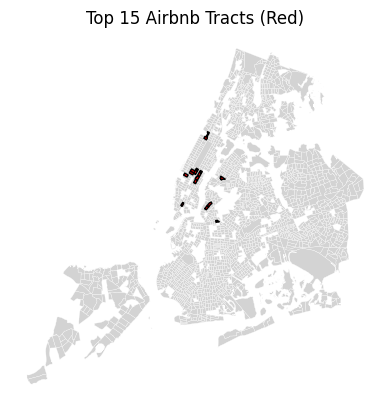

In [40]:
top_airbnb = df_merged.nlargest(15, 'listings_per_1000_residents')[['GEOID', 'Borough', 'listings_per_1000_residents', 'median_income', 'gentrification_proxy']]
print("Top 15 Airbnb Tracts:")
print(top_airbnb)

# Map just the top tracts
plt.figure(figsize=(12, 10))
gdf_final.plot(color='lightgrey', edgecolor='white', linewidth=0.2)
top_gdf = gdf_final[gdf_final['GEOID'].isin(top_airbnb['GEOID'])]
top_gdf.plot(color='red', edgecolor='black', linewidth=1, ax=plt.gca())
plt.title('Top 15 Airbnb Tracts (Red)')
plt.axis('off')
plt.savefig('top_airbnb_tracts.png', dpi=300)
plt.show()

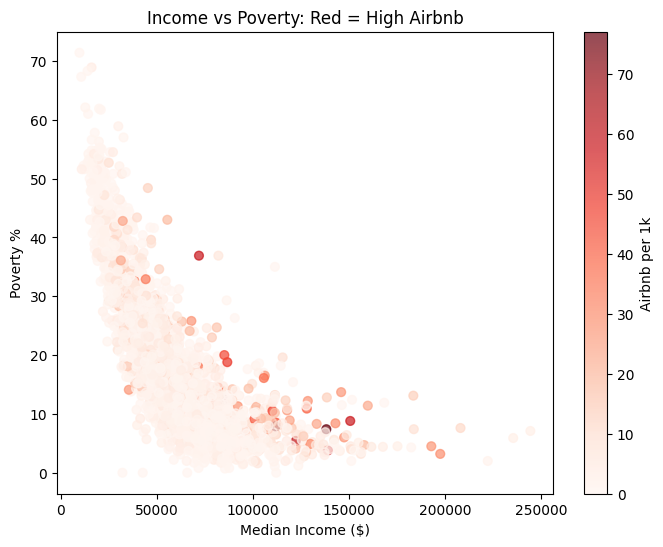

In [41]:

plt.figure(figsize=(8, 6))
plt.scatter(df_merged['median_income'], 
            df_merged['poverty_pct'],
            c=df_merged['listings_per_1000_residents'],
            cmap='Reds',
            alpha=0.7,
            s=40)
plt.xlabel('Median Income ($)')
plt.ylabel('Poverty %')
plt.title('Income vs Poverty: Red = High Airbnb')
plt.colorbar(label='Airbnb per 1k')
plt.savefig('income_poverty_airbnb.png', dpi=300)
plt.show()

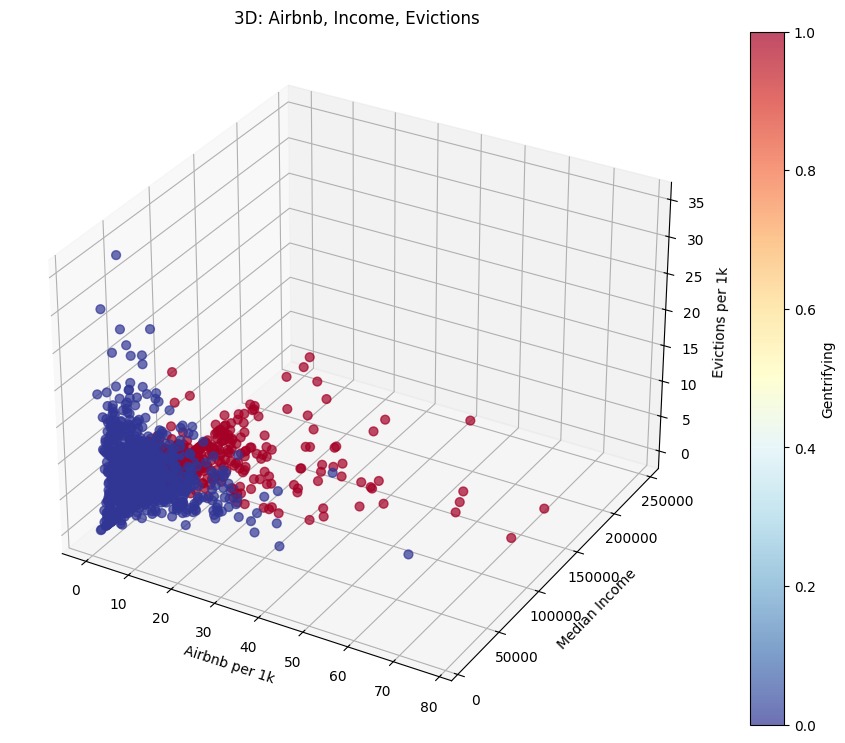

In [42]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_merged['listings_per_1000_residents'],
    df_merged['median_income'],
    df_merged['evictions_per_1000_residents'],
    c=df_merged['gentrifying'],
    cmap='RdYlBu_r',
    s=40,
    alpha=0.7
)

ax.set_xlabel('Airbnb per 1k')
ax.set_ylabel('Median Income')
ax.set_zlabel('Evictions per 1k')
plt.title('3D: Airbnb, Income, Evictions')
plt.colorbar(scatter, label='Gentrifying')
plt.savefig('3d_scatter.png', dpi=300)
plt.show()